In [1]:

######## snakemake preamble start (automatically inserted, do not edit) ########
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list('data/raw/fastq/trimmed/SRR32393053_1.fastq', 'data/raw/fastq/trimmed/SRR32393053_2.fastq', 'data/raw/fastq/trimmed/SRR32393054_1.fastq', 'data/raw/fastq/trimmed/SRR32393054_2.fastq', 'data/raw/fastq/trimmed/SRR32393055_1.fastq', 'data/raw/fastq/trimmed/SRR32393055_2.fastq', 'data/raw/fastq/trimmed/SRR32393056_1.fastq', 'data/raw/fastq/trimmed/SRR32393056_2.fastq', 'data/raw/fastq/trimmed/SRR32393057_1.fastq', 'data/raw/fastq/trimmed/SRR32393057_2.fastq'),
    output = list('data/raw/fastq/filtered/SRR32393053_1.fastq', 'data/raw/fastq/filtered/SRR32393053_2.fastq', 'data/raw/fastq/filtered/SRR32393054_1.fastq', 'data/raw/fastq/filtered/SRR32393054_2.fastq', 'data/raw/fastq/filtered/SRR32393055_1.fastq', 'data/raw/fastq/filtered/SRR32393055_2.fastq', 'data/raw/fastq/filtered/SRR32393056_1.fastq', 'data/raw/fastq/filtered/SRR32393056_2.fastq', 'data/raw/fastq/filtered/SRR32393057_1.fastq', 'data/raw/fastq/filtered/SRR32393057_2.fastq'),
    params = list(),
    wildcards = list(),
    threads = 1,
    log = list('results/reports/notebooks/filterAndTrim.r.ipynb', "notebook" = 'results/reports/notebooks/filterAndTrim.r.ipynb'),
    resources = list('tmpdir', "tmpdir" = '/tmp'),
    config = list("pathvars" = list("data_initial" = 'data/initial', "data_raw" = 'data/raw', "samples" = 'data/raw/fastq', "temp" = 'data/temp', "reports" = 'results/reports', "figures" = 'results/figures')),
    rule = 'FilterAndTrim',
    bench_iteration = as.numeric(NA),
    scriptdir = '/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression/workflow/steps/02_taxa_with_dada2/notebooks',
    source = function(...){
        old_wd <- getwd()
        on.exit(setwd(old_wd), add = TRUE)

        is_url <- grepl("^https?://", snakemake@scriptdir)
        file <- ifelse(is_url, file.path(snakemake@scriptdir, ...), ...)
        if (!is_url) setwd(snakemake@scriptdir)
        source(file)
    }
)
setwd('/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression');

######## snakemake preamble end #########


In [3]:
library(dada2); packageVersion('dada2')

Loading required package: Rcpp



[1] ‘1.38.0’

In [4]:
extract_oneside_reads <- function(reads_list, reverse=F) {
    filter_regexp = '_1\\.'
    if (reverse) {
        filter_regexp = '_2\\.'
    }
    return(
        reads_list[grepl(filter_regexp, reads_list)] |>
            as.character()
    )
}

forward_reads <- extract_oneside_reads(snakemake@input, F)
reverse_reads <- extract_oneside_reads(snakemake@input, T)

forward_reads_filtered <- extract_oneside_reads(snakemake@output, F)
reverse_reads_filtered <- extract_oneside_reads(snakemake@output, T)

In [5]:
source("workflow/scripts/reads_len_distr.R", chdir = TRUE)
reads_len_stat(forward_reads, reverse_reads)

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: BiocParallel

Loading required package: Biostrings

Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The

forward reads:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  219.0   233.0   234.0   233.7   234.0   248.0 

reverse reads:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  216.0   229.0   230.0   229.8   230.0   248.0 


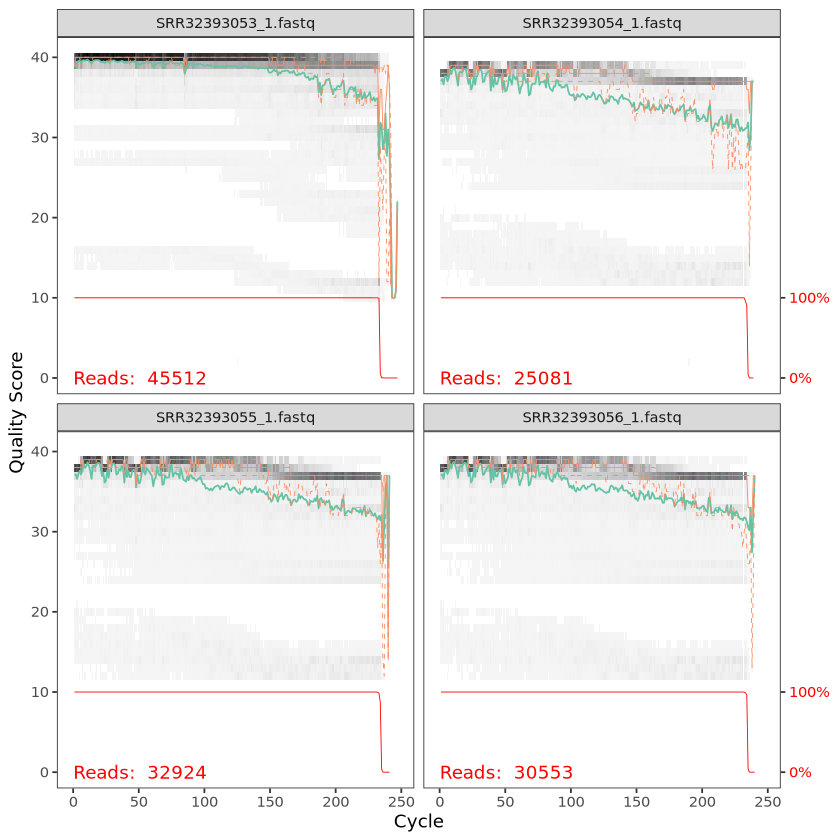

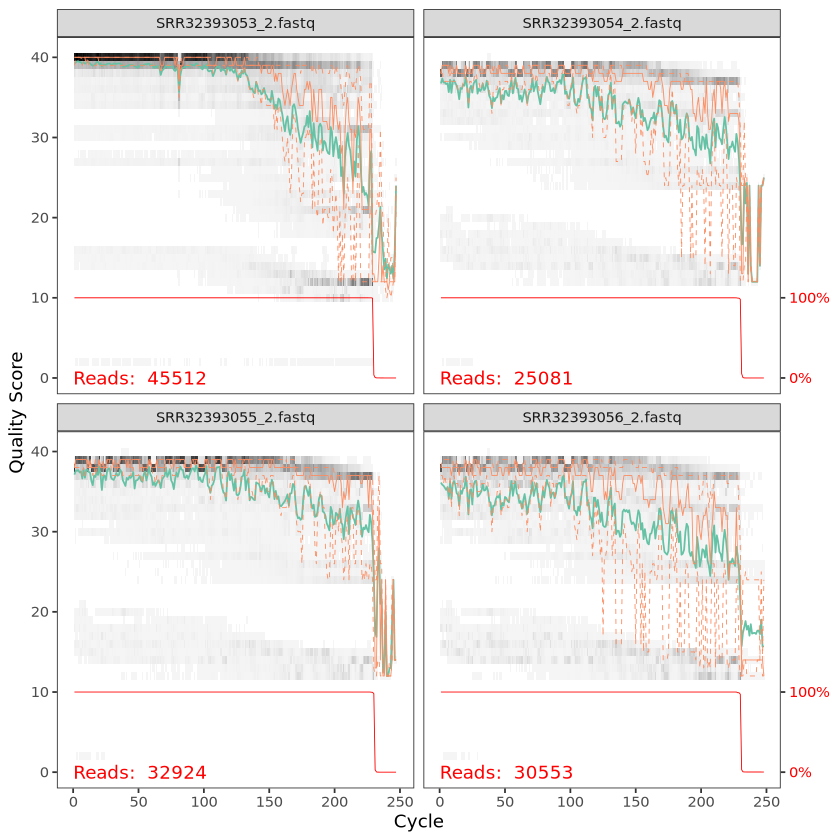

In [6]:
plotQualityProfile(forward_reads[1:4])
plotQualityProfile(reverse_reads[1:4])

In [14]:
filterAndTrim(
	forward_reads, forward_reads_filtered,
	reverse_reads, reverse_reads_filtered, 
	maxEE=c(2,2),
    rm.phix=TRUE, 
    minLen=100, 
    truncLen=c(230,230)
)

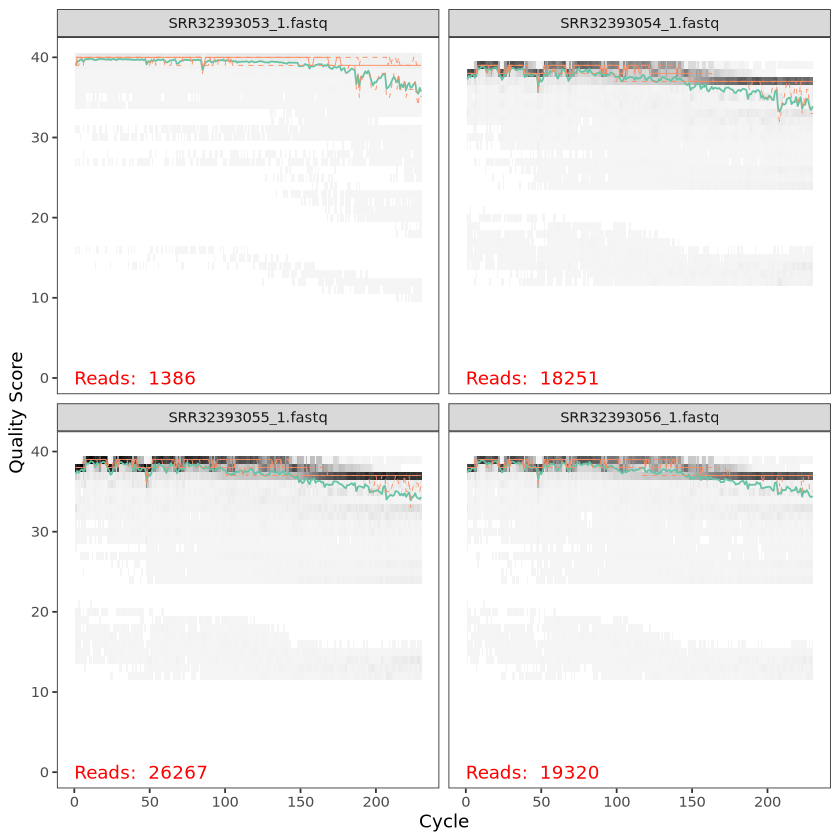

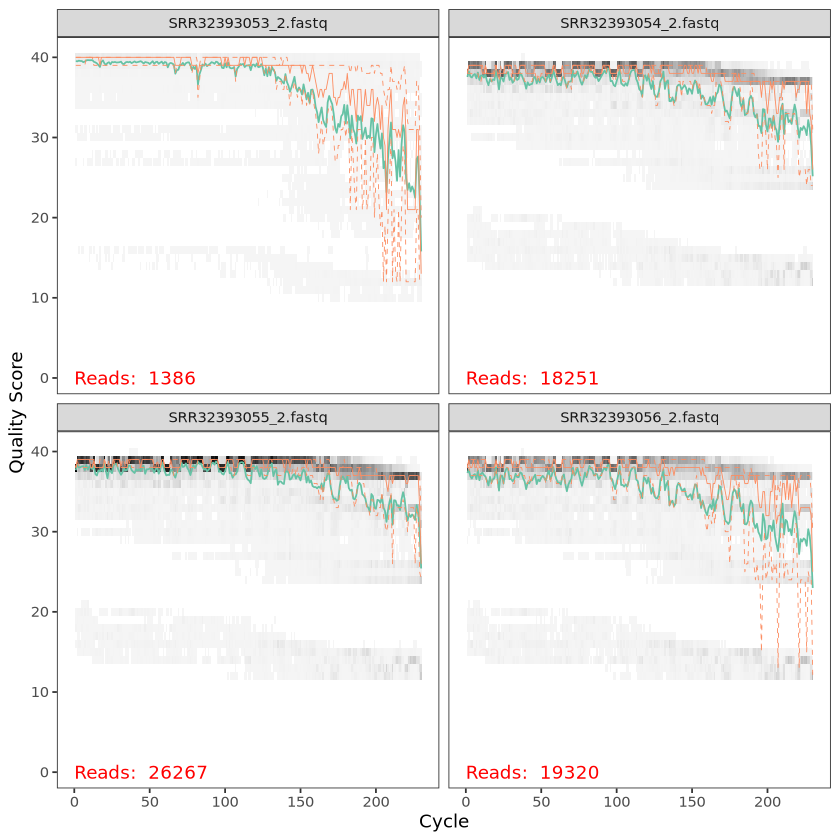

In [15]:
plotQualityProfile(forward_reads_filtered[1:4])
plotQualityProfile(reverse_reads_filtered[1:4])